# Data Analysis with Linear Models and K-Nearest Neighbors (KNN)
This noteebok aims to analyse and test data by applying linear models to evaluate which model performs beest in predicting the outcome based on the given predictors.
The dataset used in this analysis comes from the "Introduction to Data Science with Python" course offered by Harvard University on edX. 
I used the K-Nearest neighbors (KNN) algorithm to determine the optimal value of k. Then, i applied Linear Regression using a single predictor to assess the model's performance.
And for last, finally i extended the analysis to multiple Lineare Regression, comparing how model confidence changes through the R-squared metric. 
All predictors in the dataset are quantitative variables.

In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [4]:
data_path = Path.cwd()
df=pd.read_csv(data_path / "data/Advertising.csv")
print(df.head())

   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [5]:
df=df.drop(df.columns[0], axis=1)
print("Data types per column:\n", df.dtypes)
print("Shape (rows, cols):", df.shape)
print("Missing values per column:\n", df.isna().sum())

Data types per column:
 TV           float64
radio        float64
newspaper    float64
sales        float64
dtype: object
Shape (rows, cols): (200, 4)
Missing values per column:
 TV           0
radio        0
newspaper    0
sales        0
dtype: int64


In [6]:
corr_matrix = df.corr(numeric_only=True)
target_corr = corr_matrix['sales'].sort_values(ascending=False)
print(target_corr)

sales        1.000000
TV           0.782224
radio        0.576223
newspaper    0.228299
Name: sales, dtype: float64


In [7]:
#TV predictor has more correlation with the outcome
x=df['TV']
y=df['sales']

In [8]:
#ordering by the index of x, b since knn is a non-parametric model. ordering x allows for more interpretable plots.
order = np.argsort(x)
x=x[order]
y=y[order]
x_grid=np.linspace(min(x), max(x), len(x))

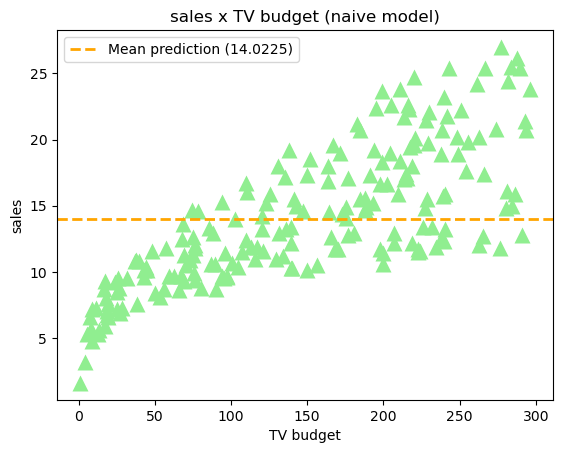

In [9]:
#Naive model plot
#The simplest possible model predicts the mean of y for every observation, this serves as a lower-bound benchmark to compare
#more complex model against
y_naive=y.mean()

plt.plot(x, y, marker= '^',linestyle= 'none', markersize= '12', markeredgecolor='none', markerfacecolor= 'lightgreen')
plt.axhline(y_naive, color='orange', linestyle='--', linewidth='2', label=f'Mean prediction ({y_naive})')
plt.title('sales x TV budget (naive model)')
plt.legend()
plt.xlabel('TV budget')
plt.ylabel('sales')
plt.show()  

In [10]:
def knn_model(x_train, y_train, k:int, x_test):
    """
    Custom implementation of KNN model algorithm.
    Parameters
    :param: x_train, Training data for the predictor variable
    :param: y_train, Training data for the response variable, corresponding to x_train
    :param: k, the number of neighbors to consider
    :x_test: x_test, Test data which predictions will be generated

    return y_pred: The outcome corresponding to x_test
    """
    y_pred=[]
    for x in x_test:
        distance= np.abs(x_train - x)
        nearests= np.argsort(distance)[:k]
        y_pred.append(np.mean(y_train.iloc[nearests]))
    return np.array(y_pred)

[]

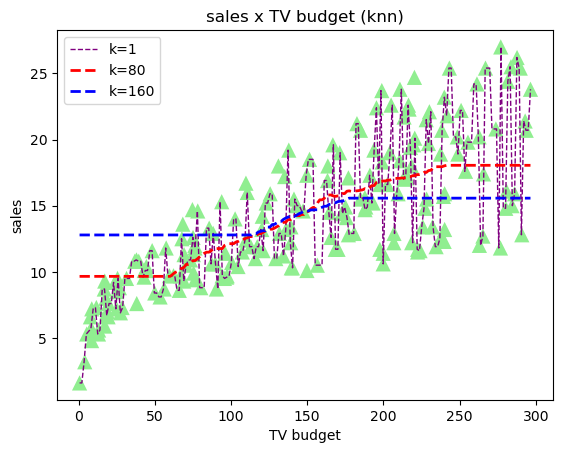

In [11]:
#KNN model plot with k= 1, 80 and 160
k_values=[1, 80, 160] # i choose this values for demonstrate how the knn_model approaches to the naive model when the k increases
pred = {k: knn_model(x,y,k, x_grid) for k in k_values}
colors= ['purple','red', 'blue']
lines=[1,2,2]
plt.scatter(x, y, marker='^', color='lightgreen', edgecolor='none', s=120)
for color, line, (i, y_hat) in zip(colors,lines, pred.items()):
    plt.plot(x_grid, y_hat, color= color, linestyle='--', label= f'k={i}', linewidth=line)
plt.title('sales x TV budget (knn)')
plt.ylabel('sales')
plt.xlabel('TV budget')
plt.legend()
plt.plot()


In [12]:
#Training the model for k in range of 1 to 9, in the following cells i explain the rationale behind these choice
#Calculating the MSE of each knn trained model as well as the R-squared (the metric allo us to evalueate the model's comparing with to a naive baseline).
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.20, random_state=42)
k_values=[_ for _ in range(1,10)]
y_pred={k: knn_model(x_train, y_train, k, x_test) for k in k_values}
mse_model={}
r2={}
y_mean_test=np.mean(y_test)
mse_media=(sum((y_test - y_mean_test) **2))/len(y_test)
for k, yz in y_pred.items():
    sumerror=0
    for i in range(len(y_test)):
        sumerror+=((y_test.iloc[i]-yz[i])**2)
    mse_model[k]=sumerror/len(y_test)
    r2[k]=1-(mse_model[k]/mse_media)

mse_model=dict(sorted(mse_model.items()))
r2=dict(sorted(r2.items()))

print(mse_media)
print(mse_model)
print(r2)
print(max(r2.values()))
#the best knn model to use so far is the one with min MSE and the max R-squared value
#note that R-squared can be also negative, meaning the model performs worse than the naive baseline.

18.50234375
{1: np.float64(17.303500000000007), 2: np.float64(16.21725), 3: np.float64(12.406055555555557), 4: np.float64(12.443296874999996), 5: np.float64(13.386219999999998), 6: np.float64(13.700638888888895), 7: np.float64(13.735418367346941), 8: np.float64(12.909027343750001), 9: np.float64(12.740231481481484)}
{1: np.float64(0.06479415614575823), 2: np.float64(0.12350293459443484), 3: np.float64(0.32948734910648514), 4: np.float64(0.32747455981083506), 5: np.float64(0.2765121986234854), 6: np.float64(0.2595187358958838), 7: np.float64(0.2576390022292748), 8: np.float64(0.3023031288265845), 9: np.float64(0.3114260737112571)}
0.32948734910648514


// MSE for every knn_model calculated //

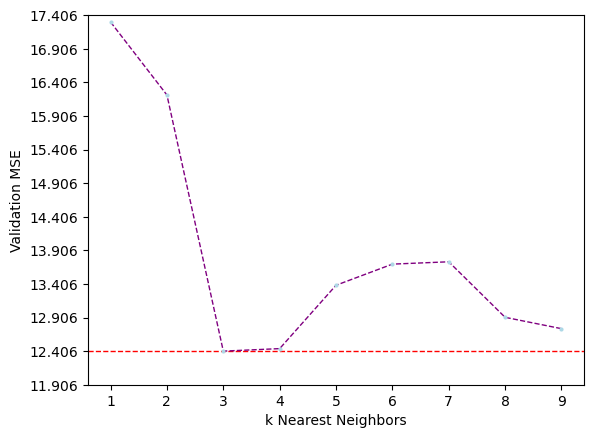

In [13]:
#Plot the MSE (Mean Squared Error) for each k value used on knn_model
ymin=min(mse_model.values())
ymax=max(mse_model.values())
plt.axhline(ymin, linestyle='--', color='red', marker='none', linewidth=1)
plt.plot(list(mse_model.keys()), list(mse_model.values()), marker='o', linestyle='--', markerfacecolor='lightblue', markeredgecolor='none', color='purple', markersize=3, linewidth=1)
plt.xlabel('k Nearest Neighbors')
plt.ylabel('Validation MSE')
plt.ylim((ymin, ymax))
plt.yticks(np.arange(ymin-0.5, ymax+0.5, 0.5))
plt.show()

In [14]:
#Now i'm using k values between 1 and 199, to explore a wider range of neighborhood sizes, this range aproximately covers the max possible gamma of the model 
#given the dataset contains 200 samples
#after split, around 160 samples are used for training and testing up to 160 neighbors allows us to capture both of the troughs, local minima, and peaks, local maxima in the MSE curve
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.20, random_state=42)
k_values=[_ for _ in range(1,161)]
y_pred={k: knn_model(x_train, y_train, k, x_test) for k in k_values}
mse_model={}
r2={}
y_mean_test=np.mean(y_test)
mse_media=(sum((y_test - y_mean_test) **2))/len(y_test)
for k, yz in y_pred.items():
    sumerror=0
    for i in range(len(y_test)):
        sumerror+=((y_test.iloc[i]-yz[i])**2)
    mse_model[k]=sumerror/len(y_test)
    r2[k]=1-(mse_model[k]/mse_media)

mse_model=dict(sorted(mse_model.items()))
r2=dict(sorted(r2.items()))

print(mse_media)
print(mse_model)
print(r2)
print(max(r2.values()))
best_k=max(r2, key=r2.get)


18.50234375
{1: np.float64(17.303500000000007), 2: np.float64(16.21725), 3: np.float64(12.406055555555557), 4: np.float64(12.443296874999996), 5: np.float64(13.386219999999998), 6: np.float64(13.700638888888895), 7: np.float64(13.735418367346941), 8: np.float64(12.909027343750001), 9: np.float64(12.740231481481484), 10: np.float64(12.798117500000002), 11: np.float64(12.09306198347107), 12: np.float64(12.910859375000001), 13: np.float64(12.190356508875738), 14: np.float64(11.992586734693877), 15: np.float64(11.52949), 16: np.float64(11.216853515624997), 17: np.float64(11.516138408304494), 18: np.float64(11.573032407407403), 19: np.float64(11.458858725761763), 20: np.float64(11.732966249999995), 21: np.float64(11.58732596371882), 22: np.float64(11.58275154958677), 23: np.float64(11.69668667296786), 24: np.float64(11.778773003472224), 25: np.float64(11.786398400000005), 26: np.float64(11.736384245562132), 27: np.float64(11.49197908093278), 28: np.float64(11.455897002551026), 29: np.float6

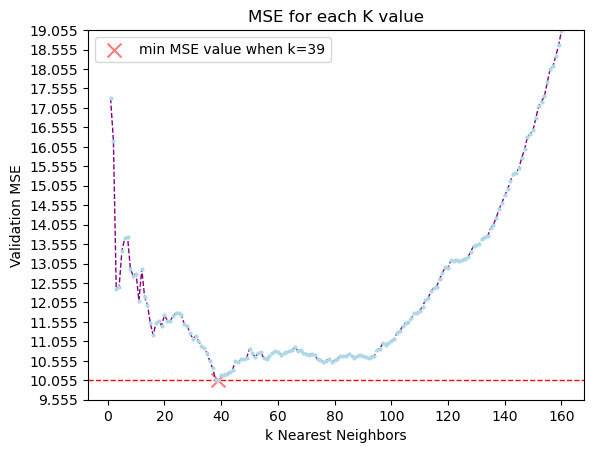

In [15]:
#Plot the MSE (Mean Squared Error) for each k value used on knn_model before.
#This visualization explains why i initially tested smaller k values. With a narrow range, we cannot confidently conclude that k=4 is optimal, since the model
#may achieve a lower MSE for higher k values. By extending the range of k values, we can observe the global minimum of the MSE curve and thus identify the mos appropriate k.
ymax=max(mse_model.values())
ymin=min(mse_model.values())
plt.axhline(ymin, linestyle='--', color='red', marker='none', linewidth=1)
plt.scatter(best_k,mse_model[best_k], marker='x', label=f'min MSE value when k={best_k}', color= "#FF7B82", s= 100)
plt.plot(list(mse_model.keys()), list(mse_model.values()), marker='o', linestyle='--', markerfacecolor='lightblue', markeredgecolor='none', color='purple', markersize=3, linewidth=1)
plt.xlabel('k Nearest Neighbors')
plt.ylabel('Validation MSE')
plt.title('MSE for each K value')
plt.ylim((ymin, ymax))
plt.legend()
plt.yticks(np.arange(ymin-0.5, ymax+0.5, 0.5))
plt.show()

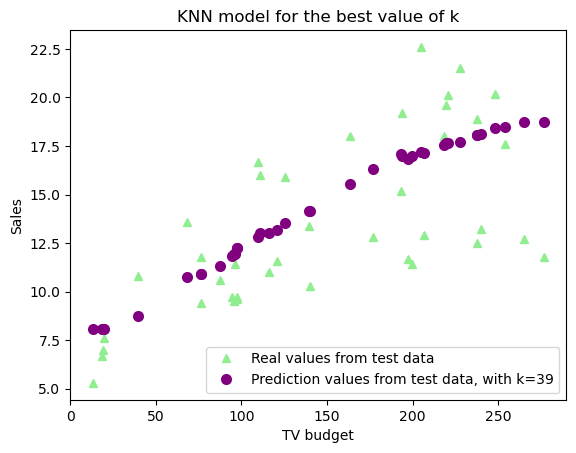

In [16]:
y_pred[best_k]
order_idx=np.argsort(x_test)
x_test_sorted=x_test.iloc[order_idx]
y_pred_sorted=y_pred[best_k][order_idx]
y_test_sorted=y_test.iloc[order_idx]
plt.plot(x_test_sorted, y_test_sorted, marker='^', color='lightgreen', label='Real values from test data' ,linestyle= 'none')
plt.plot(x_test_sorted,y_pred_sorted, marker= 'o', label =f'Prediction values from test data, with k={best_k}', linestyle='none', markerfacecolor='purple', markeredgecolor='none', markersize=8)
plt.legend()
plt.title('KNN model for the best value of k')
plt.xlabel('TV budget')
plt.ylabel('Sales')
plt.show()

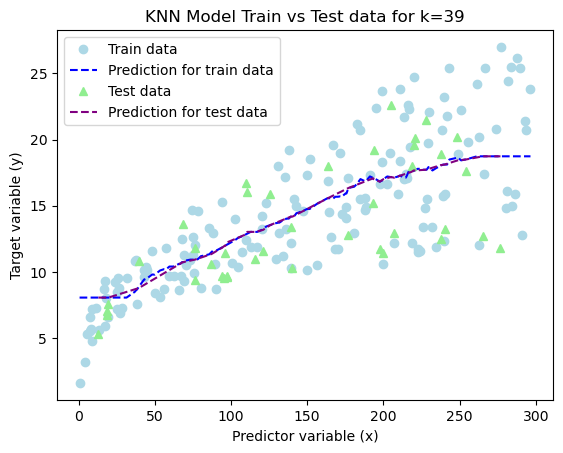

In [17]:
order_train = np.argsort(x_train)
order_test = np.argsort(x_test)
y_pred_train = knn_model(x_train, y_train, best_k, x_train)
y_pred_test = y_pred[best_k][order_test]
r2_squared_knn_train=r2_score(y_train, y_pred_train)
r2_squared_knn_test=r2_score(y_test, y_pred[best_k])
plt.plot(x_train.iloc[order_train], y_train.iloc[order_train], 
         'o', color='lightblue', label='Train data')
plt.plot(x_train.iloc[order_train], y_pred_train[order_train], 
         '--', color='blue', label='Prediction for train data')
plt.plot(x_test.iloc[order_test], y_test.iloc[order_test], 
         '^', color='lightgreen', label='Test data')
plt.plot(x_test.iloc[order_test], y_pred_test, 
         '--', color='purple', label=f'Prediction for test data')
plt.legend()
plt.xlabel('Predictor variable (x)')
plt.ylabel('Target variable (y)')
plt.title(f'KNN Model Train vs Test data for k={best_k}')
plt.show()

// Linear Regression //

In [18]:
# fit and plot a linear regression with 1 predictor. yˆhat = b0 + b1 (linear regression with 1 predictor)
def fit_and_plot(x, y, test_s=0.2, x_name='none', y_name='none'):

    x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=test_s, random_state=42)
    model = LinearRegression()

    model.fit(x_train,y_train)
    y_pred_train=model.predict(x_train)
    y_pred_test=model.predict(x_test)

    plt.scatter(x_train, y_train, marker='o', s=40, color='lightblue', label='Train data')
    plt.scatter(x_test,y_test, marker='o', color='red', s=40, label= 'Test data')
    plt.plot(x_train, y_pred_train, linestyle='-', color='purple', label='Train prediction', linewidth=1)
    plt.plot(x_test, y_pred_test, linestyle='--',label='Test prediction', color='teal', linewidth=1)
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.legend()
    plt.show()

    r2_train= r2_score(y_train, y_pred_train)
    r2_test= r2_score(y_test,y_pred_test)


    return r2_train, r2_test, model

#we're calculating the r-squared for train and test too


In [19]:
# fit a multiple linear regression model and plot predictions. Model: y^ (y hat)= Xß(X: n×p, ß: p×1, y^: n×1).
def fit_and_plot_multi(x, test_s=0.2):
    df_name_colums=list(x.columns[1:])
    x_p=np.array(x.iloc[:,:-1])
    y_p= np.array(x.iloc[:,-1])

    x_train, x_test, y_train, y_test= train_test_split(x_p, y_p, test_size=test_s, random_state=42)
    model= LinearRegression()
    model.fit(x_train, y_train)
    y_pred_train=model.predict(x_train)
    y_pred_test=model.predict(x_test)

    fig= plt.figure(figsize=(18,6))
    pairs= [(0,1), (0,2), (1,2)]
    for i, (a,b) in enumerate(pairs,1):
        ax= fig.add_subplot(1,3,i, projection= '3d')
        x1=np.linspace(x_train[:,a].min(), x_train[:,a].max(), 70)
        x2=np.linspace(x_train[:,b].min(), x_train[:,b].max(),70)
        X1,X2= np.meshgrid(x1,x2)

        others= np.mean(x_train, axis=0)
        X_pred= np.zeros((X1.size, x_train.shape[1]))
        X_pred[:,a]= X1.ravel()
        X_pred[:,b]= X2.ravel()
        for j in range(x_train.shape[1]):
            if j not in (a,b):
                X_pred[:,j]= others[j]
        y_pred=model.predict(X_pred).reshape(X1.shape)

        ax.plot_surface(X1,X2, y_pred, alpha=0.3, cmap= 'viridis', label='Prediction (gradient color)')
        ax.scatter(x_train[:,a], x_train[:,b], y_train, color='red', label='Train data', s=25)
        ax.scatter(x_test[:, a], x_test[:,b], y_test, color='blue', label= 'Test data', s=30)
        ax.set_xlabel(f'Predictor {df_name_colums[a]}')
        ax.set_ylabel(f'Predictor {df_name_colums[b]}')
        ax.set_zlabel('Sales')
        ax.view_init(15, 60)
        ax.legend()
    plt.tight_layout()
    plt.show()



    r2_train= r2_score(y_train, y_pred_train)
    r2_test= r2_score(y_test, y_pred_test)

    return r2_train, r2_test, model

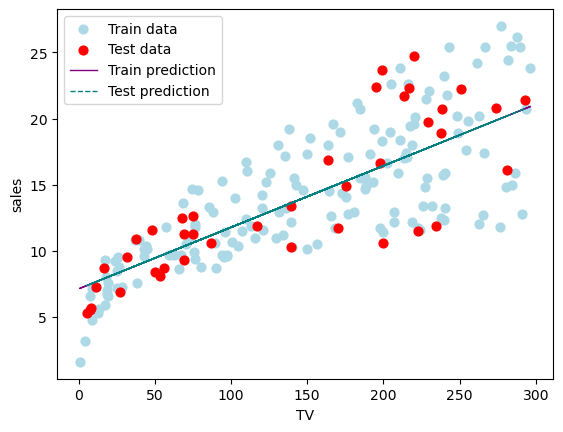

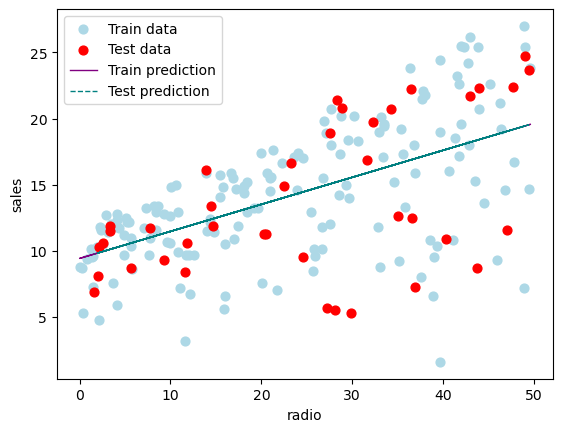

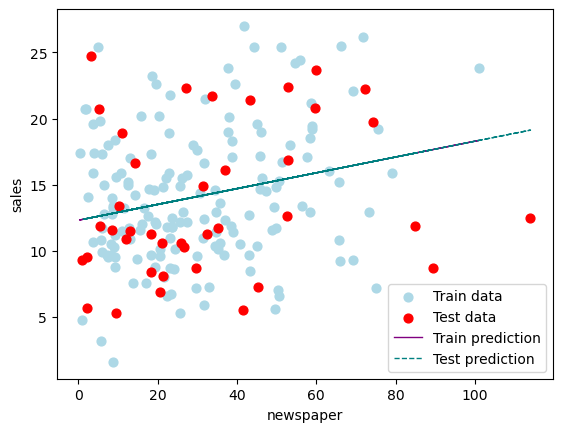

In [20]:
## calling the function for each predictor an
reg=LinearRegression()
y_name='sales'
df_names=[i for i in df.columns if i != y_name]
df_names=df_names[:]
df_models=pd.DataFrame(columns=['Predictor', 'R2_Train', 'R2_Test', 'Intercept(β0)', 'Slope(β1)', 'Slope(β2)', 'Slope(β3)' ])
df_models.loc[len(df_models)]=['KNN model', r2_squared_knn_train, r2_squared_knn_test, np.nan, np.nan, np.nan, np.nan]
for name in df_names:
    r2_train, r2_test, model= fit_and_plot(df[[name]], df[y_name], x_name=name, y_name=y_name)
    df_models.loc[len(df_models)]=[name+' LR', r2_train, r2_test, model.intercept_, model.coef_, np.nan, np.nan]

#print(f'Slope (b0): {reg_linear.intercept_}')
#print(f'Intercept (b1): {reg_linear.coef_}')

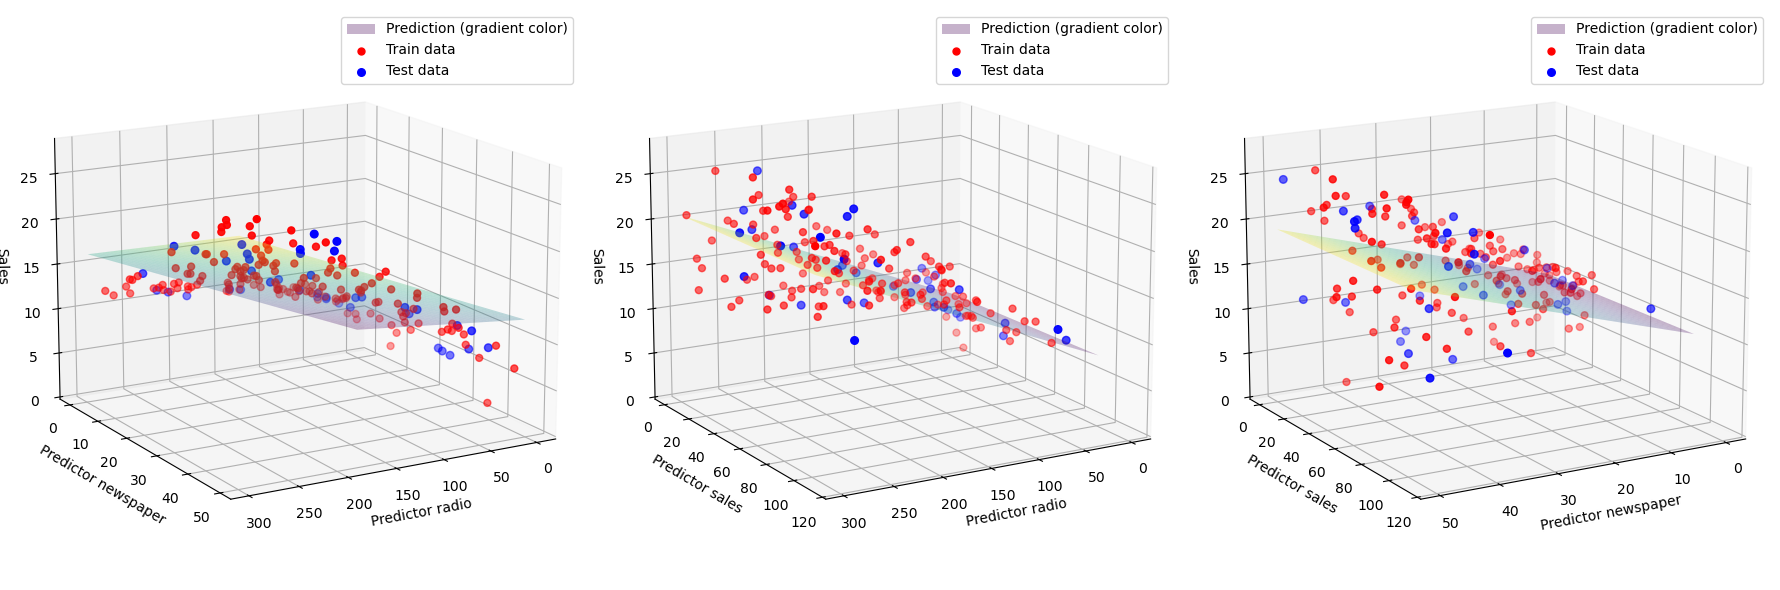

In [21]:
#linear regression with multi variables
x=df
r2_train, r2_test, model= fit_and_plot_multi(x)
list_slopes=model.coef_
df_models.loc[len(df_models)]=['Multi LR', r2_train, r2_test, model.intercept_, list_slopes[0], list_slopes[1], list_slopes[2]]

In [22]:
df_models=df_models.sort_values(by='R2_Test', ascending=True)
df_models
#the R-squared value measures how well the model explains the variability of the target variable
# an value close to 1 indicates a strong model fit, while a value close to 0 indicates a weak fit


,Predictor,R2_Train,R2_Test,Intercept(β0),Slope(β1),Slope(β2),Slope(β3)
3,newspaper LR,0.056584,0.029872,12.310548,[0.05975669788026565],NaN,NaN
2,radio LR,0.350906,0.263431,9.424066,[0.2044068457292929],NaN,NaN
0,KNN model,0.625178,0.456580,NaN,NaN,NaN,NaN
1,TV LR,0.591167,0.676695,7.119638,[0.046529733705443346],NaN,NaN
4,Multi LR,0.895701,0.899438,2.979067,0.04473,0.189195,0.002761


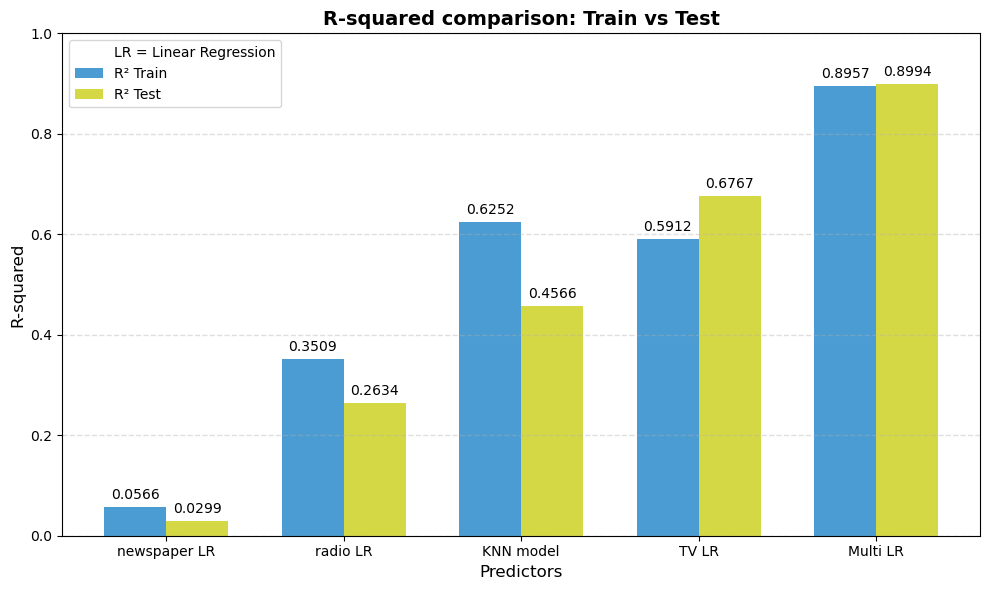

In [23]:
#a bar chart with the R-squared values to compare each model
x_bars = np.array(df_models.iloc[:, 0])
y_r2_train = np.array(df_models.iloc[:, 1])
y_r2_test = np.array(df_models.iloc[:, 2])

x = np.arange(len(x_bars))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, y_r2_train, width, color='#4B9CD3', label='R² Train')
bars2 = plt.bar(x + width/2, y_r2_test, width, color="#D4D845", label='R² Test')

plt.xlabel('Predictors', fontsize=12)
plt.ylabel('R-squared', fontsize=12)
plt.plot([],[], ' ', label='LR = Linear Regression')
plt.title('R-squared comparison: Train vs Test', fontsize=14, weight='bold')
plt.xticks(x, x_bars)
plt.ylim(0, 1.0)
plt.legend()

for bar_group in [bars1, bars2]:
    for bar in bar_group:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                 f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', linewidth=1, alpha=0.4)
plt.tight_layout()
plt.show()
